## 2 input XOR and XNOR gate

Can a linear model separate XOR?  NO!

| x1 | x2 | XOR | XNOR |
|---|---|---| ---|
| 0 | 0 | 0 | 1 |
| 0 | 1 | 1 | 0 |
| 1 | 0 | 1 | 0 |
| 1 | 1 | 0 | 1 |

<br></br>
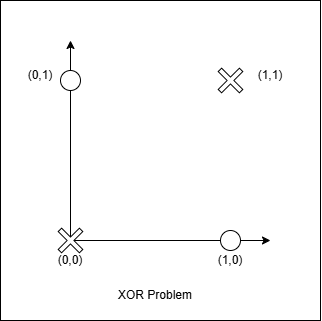


Hence, a motivation for us to study **Multi**- Layer perceptron.

## Dataset for training

In [31]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Input Data
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

# Target Output
Y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=float)

## Different activation functions

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    # Assume a = sigmoid(z)
    # =========================
    return a * (1 - a)
    # =========================
    return 

def tanh(z):
    return np.tanh(z)

def tanh_derivative(z):
    t = np.tanh(z)
    return 1 - t ** 2

## Different loss functions

In [33]:
def MSE_loss(y_pred, y_true):
  return np.mean((y_pred - y_true) ** 2) / 2

def BCE_loss(y_pred, y_true):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)) 

## Network architecture

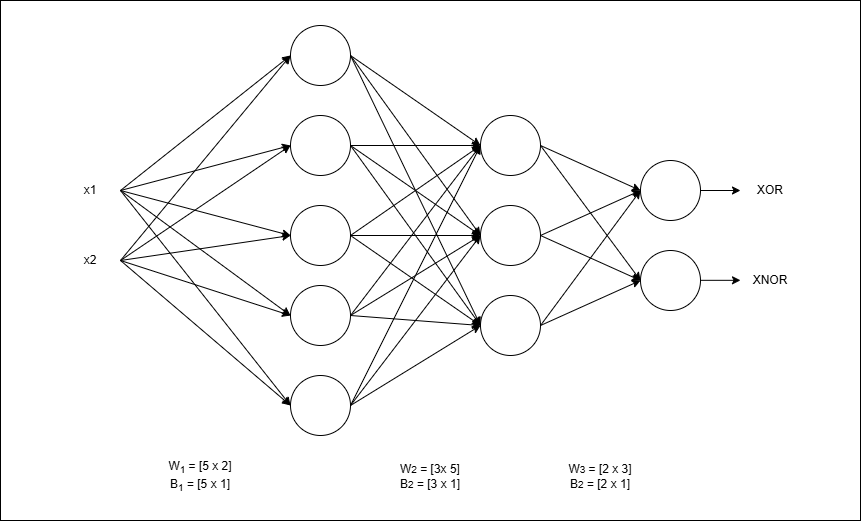

## Defining the Network

In [ ]:
class XOR_NN_Scratch:
    def __init__(self, lr=0.1):
        # Define the learning rate
        self.lr = lr

        # Define the weights and biases (learnable parameters)
        self.W1 = np.random.randn(4, 2) * 0.5
        self.b1 = np.zeros((4, 1))

        self.W2 = np.random.randn(3, 4) * 0.5
        self.b2 = np.zeros((3, 1))

        self.W3 = np.random.randn(1, 3) * 0.5
        self.b3 = np.zeros((1, 1))

    # ---------- Forward ----------
    def forward(self, X):
        # Forward pass is basically just linear equation: Z = W*X + b followed by an activation function on Z to get A 
        
        # ---- Hidden layer 1 ----
        # =========================
        self.Z1 = np.dot(self.W1, X.T) + self.b1
        self.A1 = np.tanh(self.Z1)
        # =========================
        

        # ---- Hidden layer 2 ----
        # =========================
        self.Z2 = np.dot(self.W2, self.A1) + self.b2
        self.A2 = np.tanh(self.Z2)
        # =========================


        # ---- Hidden layer 3 ----
        # =========================
        self.Z3 = np.dot(self.W3, self.A2) + self.b3
        self.A3 = np.clip(sigmoid(self.Z3), 1e-7, 1 - 1e-7)
        # =========================


        return self.A3

    # ---------- Backward ----------
    def backward(self, X, Y):
        m = X.shape[0]

        # ---- Output layer (Hidden layer 3)  ----
        # =========================
        dZ3 = self.A3 - Y.T
        dW3 = np.dot(dZ3, self.A2.T) / m
        db3 = np.sum(dZ3, axis=1, keepdims=True) / m
        # =========================
        

        # ---- Hidden layer 2 ----
        # =========================
        dA2 = np.dot(self.W3.T, dZ3)
        dZ2 = dA2 * (1 - np.tanh(self.Z2) ** 2)
        dW2 = np.dot(dZ2, self.A1.T) / m
        db2 = np.sum(dZ2, axis=1, keepdims=True) / m 
        # =========================


        # ---- Hidden layer 1 ----
        # =========================
        dA1 = np.dot(self.W2.T, dZ2)
        dZ1 = dA1 * (1 - np.tanh(self.Z1) ** 2)
        dW1 = np.dot(dZ1, X) / m
        db1 = np.sum(dZ1, axis=1, keepdims=True) / m
        # =========================


        return dW1, db1, dW2, db2, dW3, db3

    # ---------- Update ----------
    def update(self, grads):
        dW1, db1, dW2, db2, dW3, db3 = grads

        clip = 1.0

        dW1 = np.clip(dW1, -clip, clip)
        dW2 = np.clip(dW2, -clip, clip)
        dW3 = np.clip(dW3, -clip, clip)

        db1 = np.clip(db1, -clip, clip)
        db2 = np.clip(db2, -clip, clip)
        db3 = np.clip(db3, -clip, clip)

        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3
        # =========================
        

    # ---------- Training ----------
    def train(self, X, Y, epochs=5000):
        losses = []

        for epoch in range(epochs):
            Y_hat = self.forward(X)

        # loss
            loss = BCE_loss(np.clip(Y_hat, 1e-12, 1 - 1e-12), Y.T)
            loss = float(loss)

        # safety check (prevents crash)
            if np.isnan(loss) or np.isinf(loss):
                print(f"Stopped at epoch {epoch} due to explosion")
                break

            losses.append(loss)

        # backprop
            grads = self.backward(X, Y)
            self.update(grads)

            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.6f}")

        return losses

## Training the Network

In [45]:
model = XOR_NN_Scratch(lr=0.01)
losses = model.train(X, Y, epochs=5000)

Epoch 0, Loss: 0.691455
Epoch 100, Loss: 0.690068
Epoch 200, Loss: 0.688412
Epoch 300, Loss: 0.686368
Epoch 400, Loss: 0.683816
Epoch 500, Loss: 0.680632
Epoch 600, Loss: 0.676710
Epoch 700, Loss: 0.671979
Epoch 800, Loss: 0.666456
Epoch 900, Loss: 0.660334
Epoch 1000, Loss: 0.654122
Epoch 1100, Loss: 0.648679
Epoch 1200, Loss: 0.644114
Epoch 1300, Loss: 0.636445
Epoch 1400, Loss: 0.615114
Epoch 1500, Loss: 0.564051


C:\Users\Nandini Mishra\AppData\Local\Temp\ipykernel_25128\845386550.py:16: RuntimeWarning: overflow encountered in square
  return 1 - a ** 2


Epoch 1600, Loss: nan
Epoch 1700, Loss: nan
Epoch 1800, Loss: nan
Epoch 1900, Loss: nan
Epoch 2000, Loss: nan
Epoch 2100, Loss: nan
Epoch 2200, Loss: nan
Epoch 2300, Loss: nan
Epoch 2400, Loss: nan
Epoch 2500, Loss: nan
Epoch 2600, Loss: nan
Epoch 2700, Loss: nan
Epoch 2800, Loss: nan
Epoch 2900, Loss: nan
Epoch 3000, Loss: nan
Epoch 3100, Loss: nan
Epoch 3200, Loss: nan
Epoch 3300, Loss: nan
Epoch 3400, Loss: nan
Epoch 3500, Loss: nan
Epoch 3600, Loss: nan
Epoch 3700, Loss: nan
Epoch 3800, Loss: nan
Epoch 3900, Loss: nan
Epoch 4000, Loss: nan
Epoch 4100, Loss: nan
Epoch 4200, Loss: nan
Epoch 4300, Loss: nan
Epoch 4400, Loss: nan
Epoch 4500, Loss: nan
Epoch 4600, Loss: nan
Epoch 4700, Loss: nan
Epoch 4800, Loss: nan
Epoch 4900, Loss: nan


In [17]:
probs = model.forward(X).T
preds = (probs > 0.5).astype(int)

print("\nFinal predictions [XOR, XNOR]:")
print("\nInput → Output")
for x, p, pr in zip(X, preds, probs):
    print(f"{x.astype(int)} → {p} (prob={np.round(pr, 3)})")


Final predictions [XOR, XNOR]:

Input → Output
[0 0] → [0] (prob=[0.5])
[0 1] → [1] (prob=[0.558])
[1 0] → [1] (prob=[0.544])
[1 1] → [1] (prob=[0.573])


In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

NameError: name 'losses' is not defined

<Figure size 700x400 with 0 Axes>

## PyTorch Implementation

(No way we are going to write everything from scratch everytime!)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# =========================
# DATA 
# =========================

X = torch.tensor([
    [0., 0.],
    [0., 1.],
    [1., 0.],
    [1., 1.]
])

Y = torch.tensor([
    [0., 1.],  # XOR, XNOR
    [1., 0.],
    [1., 0.],
    [0., 1.]
])

# =========================
# MODEL
# =========================

class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: Define your NN below
        # =========================
        # Define 3 layers, fc1, fc2 and fc3 using nn.Linear. The shape/number of the neurons in each layer is given in the above image of the NN.
        # 2 (inputs) -> 3 (layer1) -> 5 (layer2) -> 3 (layer3) -> 2 (output)
        # Note: You dont have to seperately define Bias vectors for each layer, as it is by default True in Pytorch 
        # =========================
        # replace "pass" with your code
        pass 
        # =========================

    def forward(self, x):
        # TODO: Define forward pass of your NN below
        # =========================
        # fc1 -> tanh -> fc2 -> tanh -> fc3 -> sigmoid and then return the output
        # =========================
        # replace "pass" with your code
        pass
        # =========================
        return

model = XORNet()

# =========================
# LOSS + OPTIMIZER
# =========================

# criterion = nn.MSELoss()              # MSE loss
criterion = nn.BCELoss()              # BCE for sigmoid outputs, classification task
optimizer = optim.SGD(model.parameters(), lr=0.5)

# =========================
# TRAINING LOOP
# =========================
losses= []

for epoch in range(5000):
    # Forward pass
    y_hat = model(X)
    loss = criterion(y_hat, Y)  # criterion is the loss function

    # Backward pass = compute gradients
    optimizer.zero_grad()
    loss.backward()
    
    losses.append(loss.item())

    # Gradient descent step
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

# =========================
# EVALUATION
# =========================

with torch.no_grad():
    probs = model(X)
    preds = (probs > 0.5).int()

print("\nFinal predictions [XOR, XNOR]:")
for x, p, pr in zip(X.int(), preds, probs):
    print(f"{x.tolist()} → {p.tolist()} (prob={pr.tolist()})")

plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

ModuleNotFoundError: No module named 'torch'